<a href="https://colab.research.google.com/github/Marushikadewan/ML-and-GenAI-with-Python-2026/blob/main/marushika10601012025_week4_assignment2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

In [15]:
import numpy as np

In [16]:
import matplotlib.pyplot as plt

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

In [18]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [19]:
from sklearn.impute import SimpleImputer

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix

In [28]:
df=pd.read_csv("Loan prediction.txt")

In [29]:
print(df.head(10))

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [30]:
print("Features:")
print(df.columns[:-1])

print("Target Variables:")
print(df.columns[-1])

Features:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')
Target Variables:
Loan_Status


In [31]:
print("Rows and Columns:",df.shape)

Rows and Columns: (614, 13)


In [32]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [33]:
print(df.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [34]:
cat_cols= df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(exclude='object').columns

In [35]:
from sklearn.impute import SimpleImputer
cat_imputer=SimpleImputer(strategy='most_frequent')
num_imputer=SimpleImputer(strategy='mean')

In [36]:
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [37]:
le = LabelEncoder()
for col in cat_cols:
  df[col]=le.fit_transform(df[col])

In [38]:
scaler=StandardScaler()
num_features=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
df[num_features]= scaler.fit_transform(df[num_features])

In [39]:
X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [40]:
print('Feature Matrix(X):')
print(X.head())

Feature Matrix(X):
   Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0        0       1        0           0          0              0   
1        1       1        1           1          0              0   
2        2       1        1           0          0              1   
3        3       1        1           0          1              0   
4        4       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487    0.000000          0.279851   
1        -0.134412          -0.038732   -0.219273          0.279851   
2        -0.393747          -0.554487   -0.957641          0.279851   
3        -0.462062           0.251980   -0.314547          0.279851   
4         0.097728          -0.554487   -0.064454          0.279851   

   Credit_History  Property_Area  
0             1.0              2  
1             1.0              0  
2             1.0              2  

In [41]:
print("Target Variable(y):")
print(y.head())

Target Variable(y):
0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


In [42]:
print("shape of feature matrix:",X.shape)
print("Shape of Target Variable:",y.shape)

shape of feature matrix: (614, 12)
Shape of Target Variable: (614,)


In [43]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.select_dtypes(include='object').columns:
  df[col]=le.fit_transform(df[col])

In [45]:
X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [46]:
print("Feature Matrix(X):")
print(X.head())
print("Target Variable(y):")
print(y.head())

Feature Matrix(X):
   Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0        0       1        0           0          0              0   
1        1       1        1           1          0              0   
2        2       1        1           0          0              1   
3        3       1        1           0          1              0   
4        4       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487    0.000000          0.279851   
1        -0.134412          -0.038732   -0.219273          0.279851   
2        -0.393747          -0.554487   -0.957641          0.279851   
3        -0.462062           0.251980   -0.314547          0.279851   
4         0.097728          -0.554487   -0.064454          0.279851   

   Credit_History  Property_Area  
0             1.0              2  
1             1.0              0  
2             1.0              2  

In [47]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


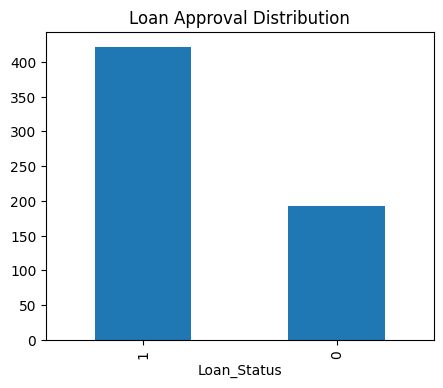

In [48]:
plt.figure(figsize=(5,4))
df['Loan_Status'].value_counts().plot(kind='bar')
plt.title('Loan Approval Distribution')
plt.show()

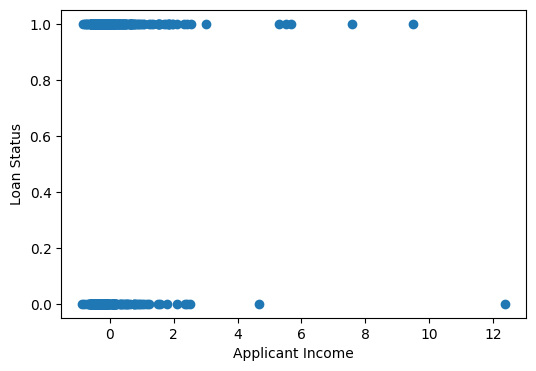

In [52]:
plt.figure(figsize=(6,4))
plt.scatter(df['ApplicantIncome'],df['Loan_Status'])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Status")
plt.show()

<Figure size 500x400 with 0 Axes>

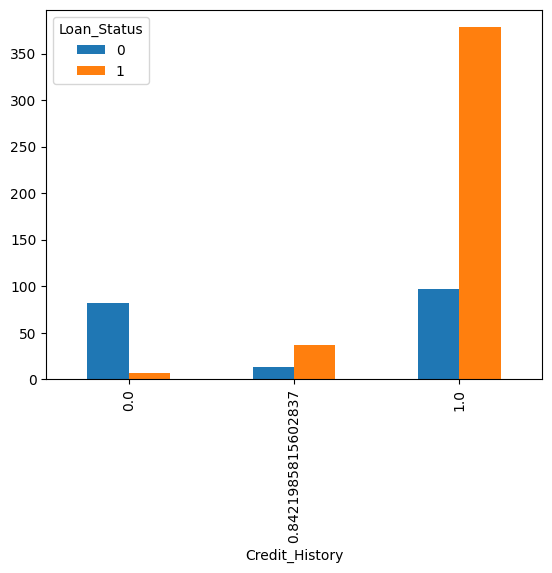

In [55]:
plt.figure(figsize=(5,4))
pd.crosstab(df['Credit_History'],df['Loan_Status']).plot(kind='bar')
plt.show()

<Figure size 500x400 with 0 Axes>

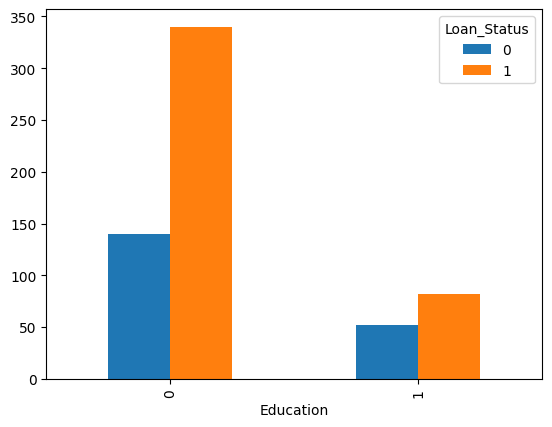

In [56]:
plt.figure(figsize=(5,4))
pd.crosstab(df['Education'],df['Loan_Status']).plot(kind='bar')
plt.show()

<Figure size 500x400 with 0 Axes>

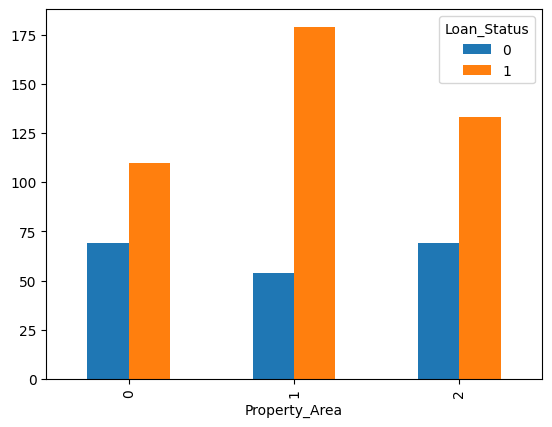

In [57]:
plt.figure(figsize=(5,4))
pd.crosstab(df['Property_Area'],df['Loan_Status']).plot(kind='bar')
plt.show()

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [59]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)

In [61]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)

In [62]:
def evaluate(name,y_test,pred):
  print(name)
  print("Accuracy:",accuracy_score(y_test,pred))
  print("Precision:",precision_score(y_test,pred))
  print("Recall:",recall_score(y_test,pred))
  print("F1 Score:",f1_score(y_test,pred))

In [63]:
evaluate("Logistic Regression",y_test,pred_lr)
evaluate("Decision Tree",y_test,pred_dt)
evaluate("Random Forest",y_test,pred_rf)

Logistic Regression
Accuracy: 0.8536585365853658
Precision: 0.8383838383838383
Recall: 0.9764705882352941
F1 Score: 0.9021739130434783
Decision Tree
Accuracy: 0.8048780487804879
Precision: 0.8351648351648352
Recall: 0.8941176470588236
F1 Score: 0.8636363636363636
Random Forest
Accuracy: 0.8455284552845529
Precision: 0.8367346938775511
Recall: 0.9647058823529412
F1 Score: 0.8961748633879781


In [64]:
results=pd.DataFrame({

'Model':['Logistic Regression','Decision Tree','Random Forest'],

'Accuracy':[accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf)],

'Precision':[precision_score(y_test,pred_lr),
precision_score(y_test,pred_dt),
precision_score(y_test,pred_rf)],

'Recall':[recall_score(y_test,pred_lr),
recall_score(y_test,pred_dt),
recall_score(y_test,pred_rf)],

'F1 Score':[f1_score(y_test,pred_lr),
f1_score(y_test,pred_dt),
f1_score(y_test,pred_rf)]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.853659   0.838384  0.976471  0.902174
1        Decision Tree  0.804878   0.835165  0.894118  0.863636
2        Random Forest  0.845528   0.836735  0.964706  0.896175


In [65]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

models={

'Logistic Regression':lr,

'Decision Tree':dt,

'Random Forest':rf

}

for name,model in models.items():

    scores=cross_val_score(model,X,y,cv=skf)

    print(name)

    print(scores)

    print("Mean:",scores.mean())

    print("Std:",scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression
[0.81300813 0.82926829 0.80487805 0.75609756 0.82786885]
Mean: 0.8062241769958683
Std: 0.026683459138513412
Decision Tree
[0.71544715 0.69105691 0.71544715 0.66666667 0.74590164]
Mean: 0.7069039051046249
Std: 0.026596842249552957
Random Forest
[0.81300813 0.82113821 0.79674797 0.74796748 0.81147541]
Mean: 0.7980674396907904
Std: 0.02625644834974801


In [66]:
param_grid={

'n_estimators':[50,100,200],

'max_depth':[3,5,10],

'min_samples_split':[2,5,10]

}

grid=GridSearchCV(RandomForestClassifier(random_state=42),

param_grid,

cv=5,

scoring='accuracy')

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [67]:
print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [68]:
print(grid.best_score_)

0.8004122861265719


In [69]:
best_model=grid.best_estimator_

pred_best=best_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_best))

Accuracy: 0.8536585365853658


In [70]:
print("Before Tuning:",accuracy_score(y_test,pred_rf))

print("After Tuning:",accuracy_score(y_test,pred_best))

Before Tuning: 0.8455284552845529
After Tuning: 0.8536585365853658


In [71]:
depths=[2,5,15]

for d in depths:

    model=DecisionTreeClassifier(max_depth=d,random_state=42)

    model.fit(X_train,y_train)

    train_acc=model.score(X_train,y_train)

    test_acc=model.score(X_test,y_test)

    print("Depth:",d)

    print("Training Accuracy:",train_acc)

    print("Testing Accuracy:",test_acc)

Depth: 2
Training Accuracy: 0.8044806517311609
Testing Accuracy: 0.8536585365853658
Depth: 5
Training Accuracy: 0.824847250509165
Testing Accuracy: 0.8373983739837398
Depth: 15
Training Accuracy: 1.0
Testing Accuracy: 0.8048780487804879
